In [151]:
import pandas as pd
import numpy as np
import networkx as nx

import seaborn as sns
import matplotlib.pyplot as plt

import random

In [27]:
edges = pd.read_csv("../data/edges.csv")[["# source", " target", " distance"]].drop_duplicates()

nodes = pd.read_csv("../data/nodes.csv")[[" id", " name", " city", " country"]]
nodes[" id"] = np.arange(0, 3214)

In [53]:
nodes.head()

,id,name,city,country
0,0,Goroka Airport,Goroka,Papua New Guinea
1,1,Madang Airport,Madang,Papua New Guinea
2,2,Mount Hagen Kagamuga Airport,Mount Hagen,Papua New Guinea
3,3,Nadzab Airport,Nadzab,Papua New Guinea
4,4,Port Moresby Jacksons International Airport,Port Moresby,Papua New Guinea


In [28]:
source_airport = np.array(edges["# source"])
destination_airport = np.array(edges[" target"])

In [ ]:
A = np.zeros((3214, 3214))

for source, target, distance in edges.values:
    A[int(source)][int(target)] = distance

G = nx.from_numpy_array(A, create_using=nx.DiGraph) # directed graph

In [47]:
G.number_of_nodes(), G.number_of_edges()


(3214, 36906)

In [50]:
G.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 

**Asortativity**

V sieti neexistuje výrazná tendencia, aby sa letiská pripájali k letiskám s podobným alebo odlišným počtom spojení.

In [48]:
r = nx.degree_assortativity_coefficient(G)
print(f"Degree assortativity coefficient: {r:.4f}") # approx. 0

Degree assortativity coefficient: -0.0192


In [55]:
density = nx.density(G)
print(f"Density: {density:.6f}") # approx. 0.0003

Density: 0.003574


In [56]:
reciprocity = nx.reciprocity(G)
print(f"Reciprocity: {reciprocity:.4f}") # approx.

Reciprocity: 0.9781


**Articulations**

In [ ]:
# Bridges and articulation points require undirected graphs
G_undirected = G.to_undirected()

In [ ]:
articulation_points = list(nx.articulation_points(G_undirected))
print(f"Number of articulation points: {len(articulation_points)}")
print(articulation_points[:10]) # first 10 articulation points

Number of articulation points: 333


In [70]:
def match_id(array, nodes_df, top_n=333):
    id_to_name = dict(zip(nodes_df[" id"].astype(int), nodes_df[" name"]))
    centrality_list = [(int(i), id_to_name.get(int(i), "Unknown")) for i in array]
    centrality_list_sorted = sorted(centrality_list, key=lambda x: x[1], reverse=True)
    for i, (nid, name) in enumerate(centrality_list_sorted[:top_n], 1):
        print(f"{i}. {name} (id={nid})")

In [71]:
match_id(articulation_points, nodes)

1. Ürümqi Diwopu International Airport (id=1675)
2. Zamboanga International Airport (id=1120)
3. Zagreb Airport (id=564)
4. Yuzhno-Sakhalinsk Airport (id=1395)
5. Yemelyanovo Airport (id=2222)
6. Yellowknife Airport (id=126)
7. Yangon International Airport (id=1557)
8. Yakutsk Airport (id=1388)
9. Xining Caojiabu Airport (id=2790)
10. Wuhan Tianhe International Airport (id=1652)
11. Wilwal International Airport (id=3069)
12. Wiley Post Will Rogers Memorial Airport (id=1752)
13. Wellington International Airport (id=959)
14. Wattay International Airport (id=1506)
15. Washington Dulles International Airport (id=1829)
16. Vnukovo International Airport (id=1437)
17. Viracopos International Airport (id=1199)
18. Vilhelmina Airport (id=363)
19. Venetie Airport (id=2987)
20. Vancouver International Airport (id=97)
21. Val de Cans/Júlio Cezar Ribeiro International Airport (id=1167)
22. Upernavik Airport (id=2267)
23. Unalaska Airport (id=1903)
24. Unalakleet Airport (id=2973)
25. Tupelo Regiona

**Bridges**

In [72]:
bridges = list(nx.bridges(G_undirected))

In [156]:
bridges

[(4, 2242),
 (4, 2249),
 (4, 2257),
 (7, 14),
 (9, 2265),
 (10, 14),
 (11, 14),
 (12, 14),
 (21, 113),
 (33, 88),
 (33, 131),
 (33, 2148),
 (34, 106),
 (34, 2308),
 (34, 3120),
 (37, 126),
 (38, 125),
 (54, 113),
 (57, 2292),
 (58, 3118),
 (63, 97),
 (69, 113),
 (78, 2298),
 (78, 3120),
 (93, 106),
 (95, 2311),
 (97, 116),
 (97, 127),
 (97, 2318),
 (97, 2332),
 (97, 3119),
 (103, 113),
 (121, 2290),
 (125, 128),
 (126, 2271),
 (126, 2310),
 (126, 2320),
 (126, 3045),
 (133, 138),
 (133, 150),
 (133, 2340),
 (142, 2338),
 (144, 2339),
 (156, 157),
 (156, 158),
 (156, 159),
 (156, 2341),
 (161, 165),
 (161, 166),
 (161, 172),
 (161, 173),
 (167, 170),
 (168, 170),
 (170, 3185),
 (183, 254),
 (184, 2906),
 (201, 205),
 (206, 597),
 (210, 618),
 (215, 216),
 (217, 218),
 (218, 220),
 (218, 223),
 (218, 225),
 (218, 227),
 (218, 232),
 (218, 233),
 (218, 372),
 (241, 261),
 (244, 2352),
 (254, 633),
 (270, 272),
 (270, 277),
 (270, 2344),
 (270, 2353),
 (275, 279),
 (279, 717),
 (295, 297),

In [76]:
len(bridges)

757

In [77]:
id_to_name = dict(zip(
    nodes[" id"].astype(int),
    nodes[" name"]
))

In [78]:
def map_bridges(bridge_list, id_to_name, top_n=None):

    mapped = []

    for u, v in bridge_list:

        mapped.append((
            int(u),
            id_to_name.get(int(u), "Unknown"),
            int(v),
            id_to_name.get(int(v), "Unknown")
        ))

    mapped_sorted = sorted(mapped, key=lambda x: x[1])

    if top_n:
        mapped_sorted = mapped_sorted[:top_n]

    for i, (u_id, u_name, v_id, v_name) in enumerate(mapped_sorted, 1):

        print(
            f"{i}. "
            f"{u_name} (id={u_id}) "
            f"<--> "
            f"{v_name} (id={v_id})"
        )

In [79]:
map_bridges(bridges, id_to_name, top_n=10)

1. Abu Simbel Airport (id=522) <--> Aswan International Airport (id=526)
2. Addis Ababa Bole International Airport (id=508) <--> Mekele Airport (id=517)
3. Adelaide International Airport (id=1627) <--> Kingscote Airport (id=2034)
4. Adelaide International Airport (id=1627) <--> Coober Pedy Airport (id=2714)
5. Adelaide International Airport (id=1627) <--> Ceduna Airport (id=2716)
6. Adelaide International Airport (id=1627) <--> Olympic Dam Airport (id=2749)
7. Adelaide International Airport (id=1627) <--> Port Augusta Airport (id=2750)
8. Adelaide International Airport (id=1627) <--> Port Lincoln Airport (id=2755)
9. Adelaide International Airport (id=1627) <--> Whyalla Airport (id=2764)
10. Adolfo Suárez Madrid–Barajas Airport (id=578) <--> Pamplona Airport (id=581)


**Articulation Removal**

In [81]:
def articulation_impact(G, articulation_points):

    original_components = nx.number_connected_components(G)

    impacts = []

    for node in articulation_points:

        G_temp = G.copy()
        G_temp.remove_node(node)

        new_components = nx.number_connected_components(G_temp)

        impacts.append((node, new_components - original_components))

    return sorted(impacts, key=lambda x: x[1], reverse=True)

In [82]:
impacts = articulation_impact(
    G_undirected,
    articulation_points
)

**Impact**

In [ ]:
# how much components increase when we remove the articulation point?

In [83]:
for node_id, impact in impacts[:20]:

    airport_name = id_to_name.get(node_id, "Unknown")

    print(
        f"{airport_name} "
        f"(id={node_id}) "
        f"-> impact: {impact}"
    )

El Dorado International Airport (id=1264) -> impact: 18
Denver International Airport (id=1853) -> impact: 15
Tokyo Haneda International Airport (id=1102) -> impact: 14
Jorge Newbery Airpark (id=1132) -> impact: 13
Ninoy Aquino International Airport (id=1115) -> impact: 13
Ted Stevens Anchorage International Airport (id=1861) -> impact: 12
Don Mueang International Airport (id=1526) -> impact: 12
Dallas Fort Worth International Airport (id=1800) -> impact: 11
Hartsfield Jackson Atlanta International Airport (id=1809) -> impact: 10
Jorge Chávez International Airport (id=1317) -> impact: 10
Licenciado Benito Juarez International Airport (id=832) -> impact: 10
Domodedovo International Airport (id=2016) -> impact: 10
Helsinki Vantaa Airport (id=218) -> impact: 10
Simón Bolívar International Airport (id=1340) -> impact: 9
Sydney Kingsford Smith International Airport (id=1639) -> impact: 9
Tribhuvan International Airport (id=1509) -> impact: 8
Perth International Airport (id=1633) -> impact: 8

**El Dorado Airport**

In [84]:
node_to_remove = 1264

G_temp = G_undirected.copy()

G_temp.remove_node(node_to_remove)

components = list(nx.connected_components(G_temp))

print(f"Number of components after removing {node_to_remove}: {len(components)}")

Number of components after removing 1264: 25


In [87]:
for i, component in enumerate(
    sorted(components, key=len, reverse=True),
    1
):

    component_sorted = sorted(component)

    print(
        f"\nComponent {i} "
        f"(size={len(component_sorted)})"
    )

    print(component_sorted[:50])  # first 50 ids


Component 1 (size=3163)
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49]

Component 2 (size=10)
[931, 932, 933, 934, 935, 936, 937, 2535, 2536, 2537]

Component 3 (size=4)
[1282, 1285, 1300, 2605]

Component 4 (size=4)
[1837, 2426, 2970, 2971]

Component 5 (size=4)
[1903, 2643, 3022, 3023]

Component 6 (size=4)
[2380, 2382, 2905, 3097]

Component 7 (size=2)
[1279, 2603]

Component 8 (size=2)
[1295, 2877]

Component 9 (size=2)
[1296, 3048]

Component 10 (size=2)
[2072, 2300]

Component 11 (size=2)
[2259, 3116]

Component 12 (size=1)
[1267]

Component 13 (size=1)
[1272]

Component 14 (size=1)
[1273]

Component 15 (size=1)
[1274]

Component 16 (size=1)
[1277]

Component 17 (size=1)
[1283]

Component 18 (size=1)
[1284]

Component 19 (size=1)
[1287]

Component 20 (size=1)
[1291]

Component 21 (size=1)
[1292]

Component 22 (size=1)
[1297]

Component 2

#### **Correlation**


=== BASIC STATISTICS ===

                  count       mean        std  min  25%   50%   75%    max
is_articulation                                                           
0                2881.0   8.509545  18.398954  1.0  2.0   3.0   7.0  248.0
1                 333.0  39.639640  47.510961  2.0  6.0  20.0  54.0  240.0

=== CORRELATION ===

Correlation between degree and articulation status: 0.3790

=== MEAN DEGREE ===

Articulation points mean degree: 39.64
Non-articulation nodes mean degree: 8.51

=== TOP ARTICULATION POINTS BY DEGREE ===

      node_id                                      airport_name  degree
628       628           Charles de Gaulle International Airport     240
770       770                     Atatürk International Airport     233
1809     1809  Hartsfield Jackson Atlanta International Airport     217
1885     1885              Chicago O'Hare International Airport     206
1800     1800           Dallas Fort Worth International Airport     188
2016     2016 

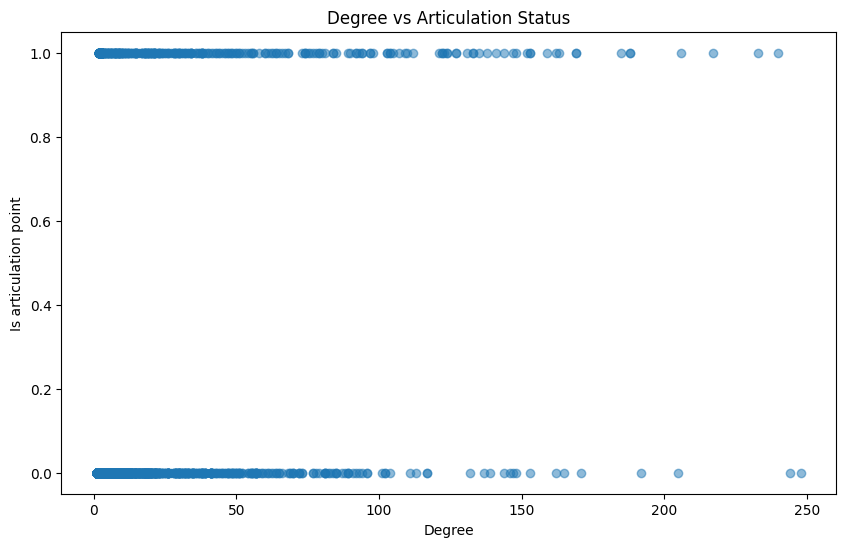

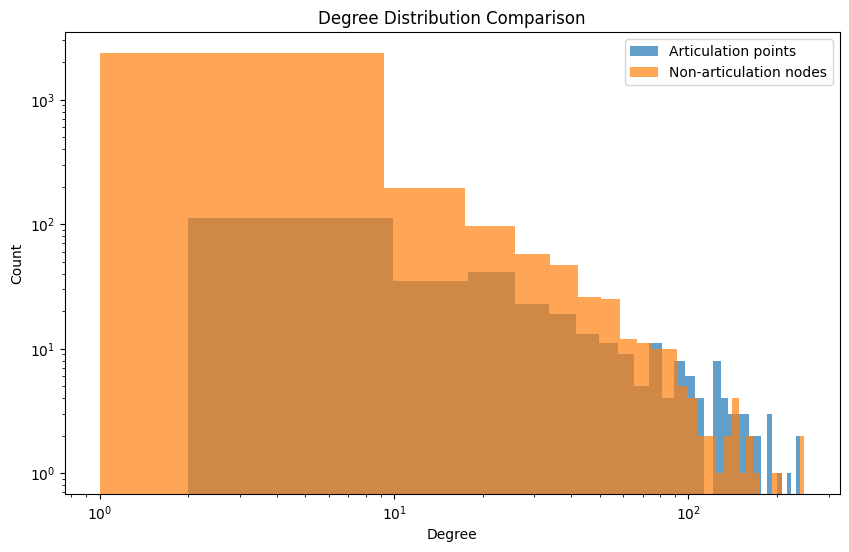

In [90]:
articulation_points = set(nx.articulation_points(G_undirected))

# --------------------------------------------
# Compute node degrees
# --------------------------------------------

degrees = dict(G_undirected.degree())

# --------------------------------------------
# Build dataframe
# --------------------------------------------

rows = []

for node in G_undirected.nodes():

    rows.append({
        "node_id": node,
        "airport_name": id_to_name.get(node, "Unknown"),
        "degree": degrees[node],
        "is_articulation": int(node in articulation_points)
    })

df = pd.DataFrame(rows)

# --------------------------------------------
# Basic statistics
# --------------------------------------------

print("\n=== BASIC STATISTICS ===\n")

print(df.groupby("is_articulation")["degree"].describe())

# --------------------------------------------
# Correlation
# --------------------------------------------

correlation = df["degree"].corr(df["is_articulation"])

print("\n=== CORRELATION ===\n")
print(f"Correlation between degree and articulation status: {correlation:.4f}")

# --------------------------------------------
# Mean degrees
# --------------------------------------------

mean_art = df[df["is_articulation"] == 1]["degree"].mean()
mean_non = df[df["is_articulation"] == 0]["degree"].mean()

print("\n=== MEAN DEGREE ===\n")
print(f"Articulation points mean degree: {mean_art:.2f}")
print(f"Non-articulation nodes mean degree: {mean_non:.2f}")

# --------------------------------------------
# Top articulation points by degree
# --------------------------------------------

print("\n=== TOP ARTICULATION POINTS BY DEGREE ===\n")

top_articulations = (
    df[df["is_articulation"] == 1]
    .sort_values("degree", ascending=False)
)

print(
    top_articulations[
        ["node_id", "airport_name", "degree"]
    ].head(20)
)

# --------------------------------------------
# Scatter plot
# --------------------------------------------

plt.figure(figsize=(10,6))

plt.scatter(
    df["degree"],
    df["is_articulation"],
    alpha=0.5
)

plt.xlabel("Degree")
plt.ylabel("Is articulation point")
plt.title("Degree vs Articulation Status")

plt.show()

# --------------------------------------------
# Histogram comparison
# --------------------------------------------

plt.figure(figsize=(10,6))

plt.hist(
    df[df["is_articulation"] == 1]["degree"],
    bins=30,
    alpha=0.7,
    label="Articulation points"
)

plt.hist(
    df[df["is_articulation"] == 0]["degree"],
    bins=30,
    alpha=0.7,
    label="Non-articulation nodes"
)

plt.xlabel("Degree")
plt.ylabel("Count")
plt.xscale("log")
plt.yscale("log")
plt.title("Degree Distribution Comparison")

plt.legend()

plt.show()

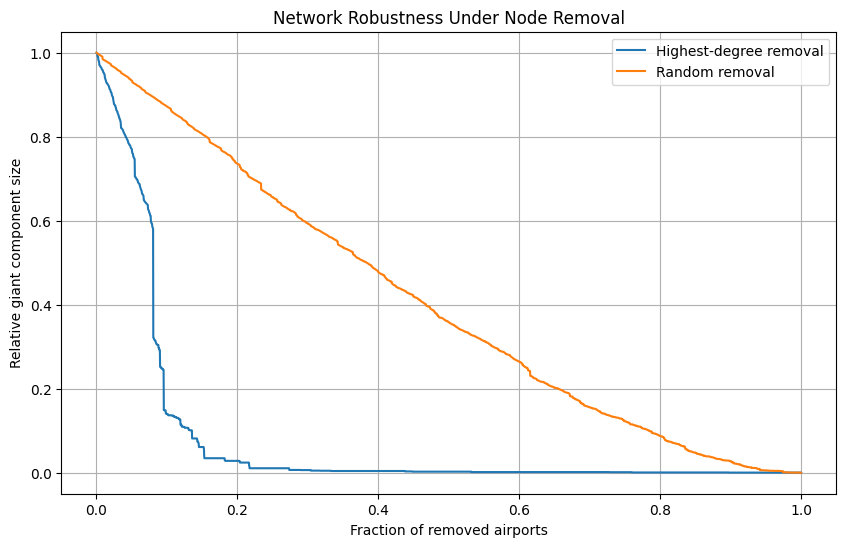

In [102]:
def sequential_removal_analysis(
    G,
    strategy="highest_degree"
):

    G_temp = G.copy()

    original_size = len(max(nx.connected_components(G_temp), key=len))

    removed_fraction = []
    giant_component_fraction = []

    removed_nodes = 0

    # ------------------------------------------------------
    # Removal order
    # ------------------------------------------------------

    if strategy == "highest_degree":

        removal_order = sorted(
            G_temp.degree,
            key=lambda x: x[1],
            reverse=True
        )

        removal_order = [node for node, degree in removal_order]

    elif strategy == "random":

        removal_order = list(G_temp.nodes())
        random.shuffle(removal_order)

    else:
        raise ValueError("Unknown strategy")

    # ------------------------------------------------------
    # Sequential removal
    # ------------------------------------------------------

    for node in removal_order:

        G_temp.remove_node(node)

        removed_nodes += 1

        if len(G_temp.nodes()) > 0:

            largest_cc = max(
                nx.connected_components(G_temp),
                key=len
            )

            giant_size = len(largest_cc)

        else:

            giant_size = 0

        removed_fraction.append(
            removed_nodes / G.number_of_nodes()
        )

        giant_component_fraction.append(
            giant_size / original_size
        )

    return removed_fraction, giant_component_fraction


# ==========================================================
# RUN ANALYSIS
# ==========================================================

# ----------------------------------------------------------
# Targeted attack:
# remove highest-degree hubs first
# ----------------------------------------------------------

x_degree, y_degree = sequential_removal_analysis(
    G_undirected,
    strategy="highest_degree"
)

# ----------------------------------------------------------
# Random failures
# ----------------------------------------------------------

x_random, y_random = sequential_removal_analysis(
    G_undirected,
    strategy="random"
)

# ==========================================================
# PLOT
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    x_degree,
    y_degree,
    label="Highest-degree removal"
)

plt.plot(
    x_random,
    y_random,
    label="Random removal"
)

plt.xlabel("Fraction of removed airports")
plt.ylabel("Relative giant component size")

plt.title("Network Robustness Under Node Removal")

plt.legend()

plt.grid(True)

plt.show()

In [99]:
def sequential_dynamic_articulation_removal(G):

    G_temp = G.copy()

    original_size = len(max(nx.connected_components(G_temp), key=len))
    original_n = G.number_of_nodes()

    removed_fraction = []
    giant_component_fraction = []
    number_of_components = []
    removed_nodes = []

    while G_temp.number_of_nodes() > 0:

        articulations = list(nx.articulation_points(G_temp))

        if len(articulations) > 0:
            # choose the articulation with highest degree
            node_to_remove = max(
                articulations,
                key=lambda node: G_temp.degree[node]
            )
        else:
            # if no articulations remain, remove highest-degree node
            node_to_remove = max(
                G_temp.nodes(),
                key=lambda node: G_temp.degree[node]
            )

        G_temp.remove_node(node_to_remove)
        removed_nodes.append(node_to_remove)

        if G_temp.number_of_nodes() > 0:
            giant_size = len(max(nx.connected_components(G_temp), key=len))
            components_count = nx.number_connected_components(G_temp)
        else:
            giant_size = 0
            components_count = 0

        removed_fraction.append(
            len(removed_nodes) / original_n
        )

        giant_component_fraction.append(
            giant_size / original_size
        )

        number_of_components.append(components_count)

    return removed_fraction, giant_component_fraction, number_of_components, removed_nodes

In [175]:
def sequential_removal_analysis(G, strategy="highest_degree", seed=42):
    """
    Strategies:
    - "random"
    - "highest_degree"
    - "dynamic_highest_degree"
    - "articulation"
    - "dynamic_articulation"
    """
    global txt

    random.seed(seed)
    

    G_temp = G.copy()
    original_n = G.number_of_nodes()
    original_size = len(max(nx.connected_components(G_temp), key=len))

    removed_fraction = []
    giant_component_fraction = []
    number_of_components = []
    removed_nodes = []

    # fixed removal order strategies
    if strategy == "random":
        removal_order = list(G_temp.nodes())
        random.shuffle(removal_order)

    elif strategy == "highest_degree":
        removal_order = [
            node for node, degree in sorted(
                G_temp.degree,
                key=lambda x: x[1],
                reverse=True
            )
        ]

    elif strategy == "articulation":
        articulations = list(nx.articulation_points(G_temp))

        non_articulations = [
            node for node in G_temp.nodes()
            if node not in articulations
        ]

        removal_order = articulations + non_articulations

    elif strategy in ["dynamic_highest_degree", "dynamic_articulation"]:
        removal_order = None

    else:
        raise ValueError(
            "Unknown strategy. Use: random, highest_degree, "
            "dynamic_highest_degree, articulation, dynamic_articulation"
        )

    while G_temp.number_of_nodes() > 0:

        if strategy == "dynamic_highest_degree":
            node_to_remove = max(
                G_temp.nodes(),
                key=lambda node: G_temp.degree[node]
            )

        elif strategy == "dynamic_articulation":
            articulations = list(nx.articulation_points(G_temp))

            if len(articulations) > 0:
                node_to_remove = max(
                    articulations,
                    key=lambda node: G_temp.degree[node]
                )
            else:
                node_to_remove = max(
                    G_temp.nodes(),
                    key=lambda node: G_temp.degree[node]
                )

        else:
            node_to_remove = removal_order[len(removed_nodes)]

        G_temp.remove_node(node_to_remove)
        if strategy in ["dynamic_articulation"]:
            txt += f"{node_to_remove} "
        removed_nodes.append(node_to_remove)

        if G_temp.number_of_nodes() > 0:
            largest_cc = max(nx.connected_components(G_temp), key=len)
            giant_size = len(largest_cc)
            components_count = nx.number_connected_components(G_temp)
        else:
            giant_size = 0
            components_count = 0

        removed_fraction.append(len(removed_nodes) / original_n)
        giant_component_fraction.append(giant_size / original_size)
        number_of_components.append(components_count)

    return removed_fraction, giant_component_fraction, number_of_components, removed_nodes

In [114]:
strategies = [
    "random",
    "highest_degree",
    "dynamic_highest_degree",
    "dynamic_articulation"
]

In [176]:
results = {}
txt = ""

for strategy in strategies:
    results[strategy] = sequential_removal_analysis(
        G_undirected,
        strategy=strategy
    )

In [177]:
txt

'628 770 1809 1885 2016 1800 1017 1853 1744 570 706 279 578 1679 1642 184 1715 1435 1913 125 1914 1753 1485 1789 1990 1901 629 1607 368 1919 1829 1854 1721 1408 1671 977 295 282 201 315 1658 1646 1915 1870 739 1952 2183 566 579 1712 1669 1493 1699 253 1655 1650 1736 1738 832 1639 716 492 1445 1731 692 247 381 1115 1708 1754 618 1102 1943 982 1019 1662 1437 1264 1667 614 1850 523 218 1647 508 1429 1659 1818 2040 1610 97 762 1199 1190 1894 1589 1652 750 2115 284 270 288 185 240 242 255 624 133 1790 1678 1676 2099 1056 1132 1626 1962 1021 176 1675 1317 864 760 113 1013 3204 718 573 1169 204 731 939 1651 1526 1602 1434 674 639 666 1000 1834 1806 1545 1401 972 1340 2767 1666 2851 1775 1750 2193 308 849 853 89 2128 1670 1542 1644 1063 334 709 2049 1172 1363 1716 3111 1471 783 170 4 771 195 1841 818 1861 1633 1377 978 433 254 597 245 619 737 1221 1241 1513 1951 1111 1058 1011 1416 2135 2017 1953 1612 630 1026 1378 1983 833 1223 1661 48 31 1765 1838 898 1558 2222 868 161 930 2084 1664 1645 109

In [179]:
with open("dynamic_articulation_removal_order.txt", "w", encoding="utf-8") as f:
    f.write(txt)

**Network Robustness Under Node Removal**

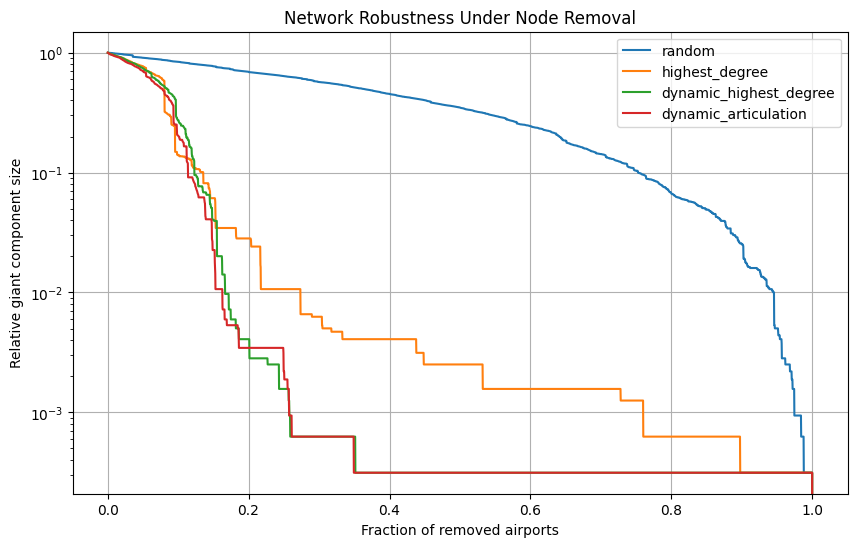

In [119]:
plt.figure(figsize=(10,6))

for strategy in strategies:
    x, y, components, removed = results[strategy]
    plt.plot(x, y, label=strategy)

plt.xlabel("Fraction of removed airports")
plt.ylabel("Relative giant component size")
plt.title("Network Robustness Under Node Removal")
plt.legend()
plt.yscale("log")
plt.grid(True)
plt.show()

**Network Fragmentation Under Node Removal**

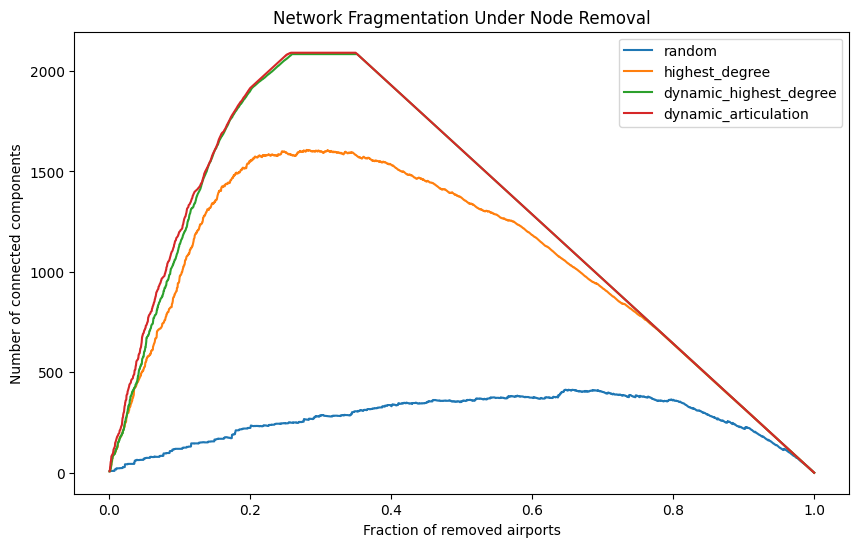

In [116]:
plt.figure(figsize=(10,6))

for strategy in strategies:
    x, y, components, removed = results[strategy]
    plt.plot(x, components, label=strategy)

plt.xlabel("Fraction of removed airports")
plt.ylabel("Number of connected components")
plt.title("Network Fragmentation Under Node Removal")
plt.legend()
plt.grid(False)
plt.show()

**Difference**

In [136]:
(np.array(results["dynamic_highest_degree"][1]) - np.array(results["dynamic_articulation"][1])).mean() * 100



np.float64(0.6545332957520384)

In [137]:
x_deg, y_deg, c_deg, r_deg = results["dynamic_highest_degree"]
x_art, y_art, c_art, r_art = results["dynamic_articulation"]

# convert to numpy arrays
y_deg = np.array(y_deg)
y_art = np.array(y_art)

# percentage changes
pct_deg = (
    (y_deg[1:] - y_deg[:-1])
    / y_deg[:-1]
) * 100

pct_art = (
    (y_art[1:] - y_art[:-1])
    / y_art[:-1]
) * 100

**Relative percentual drops**

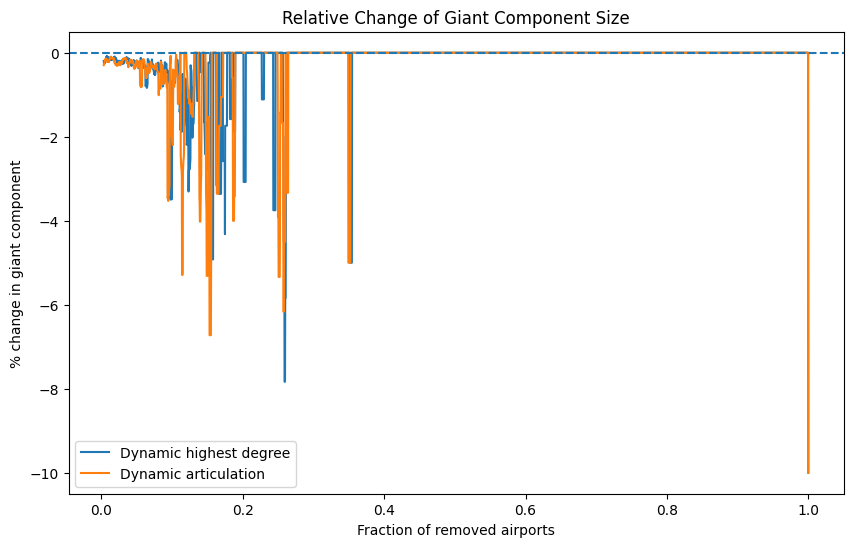

In [ ]:
plt.figure(figsize=(10,6))

plt.plot(
    x_deg[1:],
    pct_deg,
    label="Dynamic highest degree"
)

plt.plot(
    x_art[1:],
    pct_art,
    label="Dynamic articulation"
)

plt.axhline(0, linestyle="--")

plt.xlabel("Fraction of removed airports")
plt.ylabel("% change in giant component")

plt.title(
    "Relative Change of Giant Component Size"
)

plt.legend()
plt.grid(False)

plt.show()

In [149]:
sum(pct_deg) / len(pct_deg), sum(pct_art) / len(pct_art)

(np.float64(-0.2515729523519712), np.float64(-0.25665156398067346))

**a.k.a ROC AUC**

In [154]:
np.trapezoid(y_deg, x_deg)

np.float64(0.07878784122787773)

In [ ]:
np.trapezoid(y_art, x_art) # faster collapse, smaller area

np.float64(0.07224255706878394)

#### **Bridges**

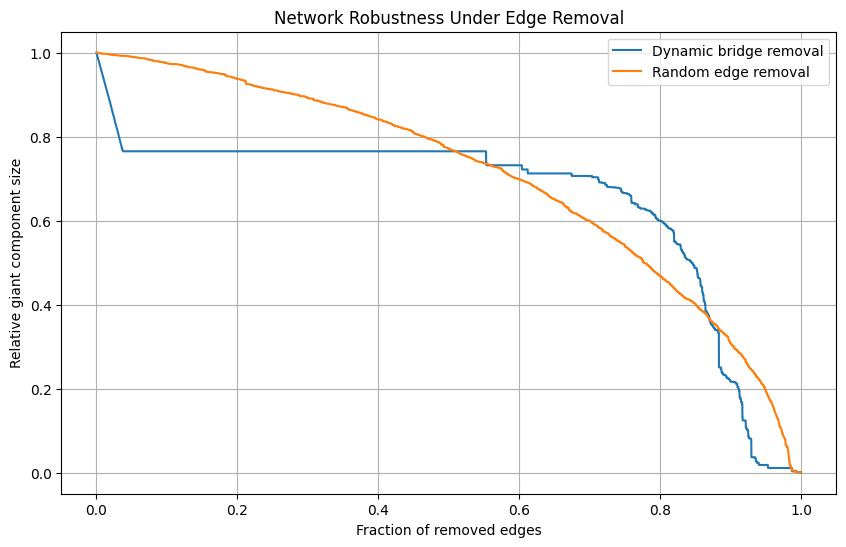

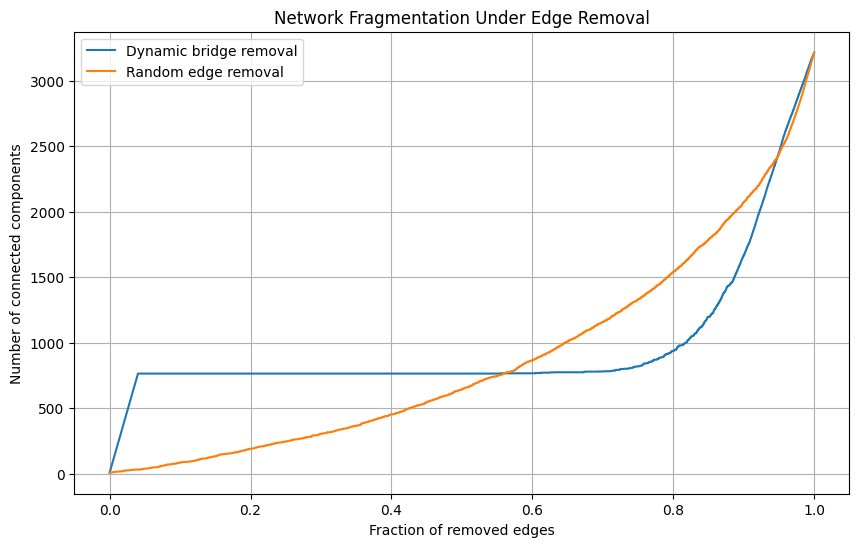

In [ ]:
# ==========================================================
# DYNAMIC BRIDGE REMOVAL
# ==========================================================

def dynamic_bridge_removal_analysis(G, seed=42):

    random.seed(seed)

    G_temp = G.copy()

    original_n = G.number_of_nodes()
    original_size = len(max(nx.connected_components(G_temp), key=len))

    removed_fraction = []
    giant_component_fraction = []
    number_of_components = []

    removed_edges = []

    while G_temp.number_of_edges() > 0:

        bridges = list(nx.bridges(G_temp))

        # --------------------------------------------------
        # choose bridge to remove
        # --------------------------------------------------

        if len(bridges) > 0:

            # remove bridge connecting highest-degree vertices
            edge_to_remove = max(
                bridges,
                key=lambda edge:
                    G_temp.degree[edge[0]] +
                    G_temp.degree[edge[1]]
            )

        else:

            # if no bridges remain,
            # remove highest-degree edge
            edge_to_remove = max(
                G_temp.edges(),
                key=lambda edge:
                    G_temp.degree[edge[0]] +
                    G_temp.degree[edge[1]]
            )

        G_temp.remove_edge(*edge_to_remove)

        removed_edges.append(edge_to_remove)

        # --------------------------------------------------
        # metrics
        # --------------------------------------------------

        if G_temp.number_of_nodes() > 0:

            largest_cc = max(
                nx.connected_components(G_temp),
                key=len
            )

            giant_size = len(largest_cc)

            components_count = nx.number_connected_components(G_temp)

        else:

            giant_size = 0
            components_count = 0

        removed_fraction.append(
            len(removed_edges) / G.number_of_edges()
        )

        giant_component_fraction.append(
            giant_size / original_size
        )

        number_of_components.append(
            components_count
        )

    return (
        removed_fraction,
        giant_component_fraction,
        number_of_components,
        removed_edges
    )


# ==========================================================
# RANDOM EDGE REMOVAL
# ==========================================================

def random_edge_removal_analysis(G, seed=42):

    random.seed(seed)

    G_temp = G.copy()

    original_size = len(max(nx.connected_components(G_temp), key=len))

    edges = list(G_temp.edges())
    random.shuffle(edges)

    removed_fraction = []
    giant_component_fraction = []
    number_of_components = []

    removed_edges = []

    for edge in edges:

        if G_temp.has_edge(*edge):

            G_temp.remove_edge(*edge)

            removed_edges.append(edge)

            if G_temp.number_of_nodes() > 0:

                largest_cc = max(
                    nx.connected_components(G_temp),
                    key=len
                )

                giant_size = len(largest_cc)

                components_count = nx.number_connected_components(G_temp)

            else:

                giant_size = 0
                components_count = 0

            removed_fraction.append(
                len(removed_edges) / G.number_of_edges()
            )

            giant_component_fraction.append(
                giant_size / original_size
            )

            number_of_components.append(
                components_count
            )

    return (
        removed_fraction,
        giant_component_fraction,
        number_of_components,
        removed_edges
    )


In [ ]:
# run

x_bridge, y_bridge, c_bridge, r_bridge = (
    dynamic_bridge_removal_analysis(G_undirected)
)

x_random, y_random, c_random, r_random = (
    random_edge_removal_analysis(G_undirected)
)

**Network Robustness Under Edge Removal**

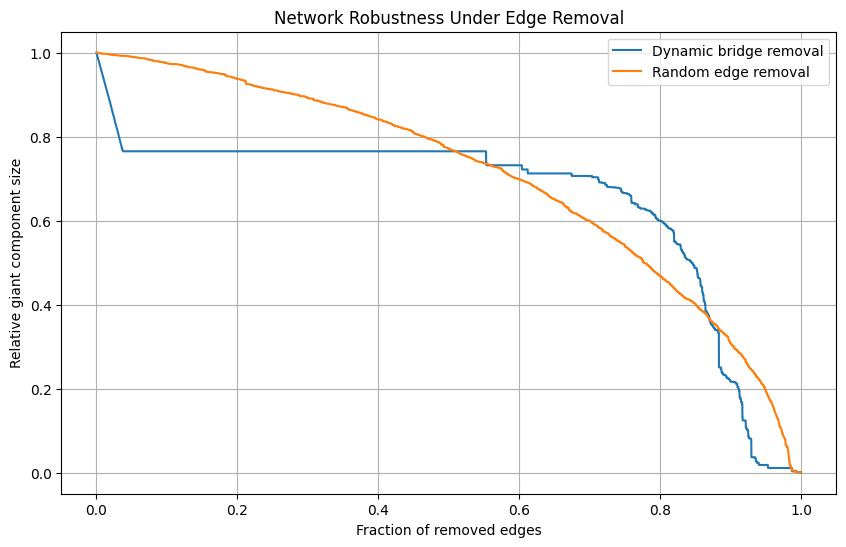

In [158]:
# plot giant component

plt.figure(figsize=(10,6))

plt.plot(
    x_bridge,
    y_bridge,
    label="Dynamic bridge removal"
)

plt.plot(
    x_random,
    y_random,
    label="Random edge removal"
)

plt.xlabel("Fraction of removed edges")
plt.ylabel("Relative giant component size")

plt.title(
    "Network Robustness Under Edge Removal"
)

plt.legend()
plt.grid(True)

plt.show()

**Network Fragmentation Under Edge Removal**

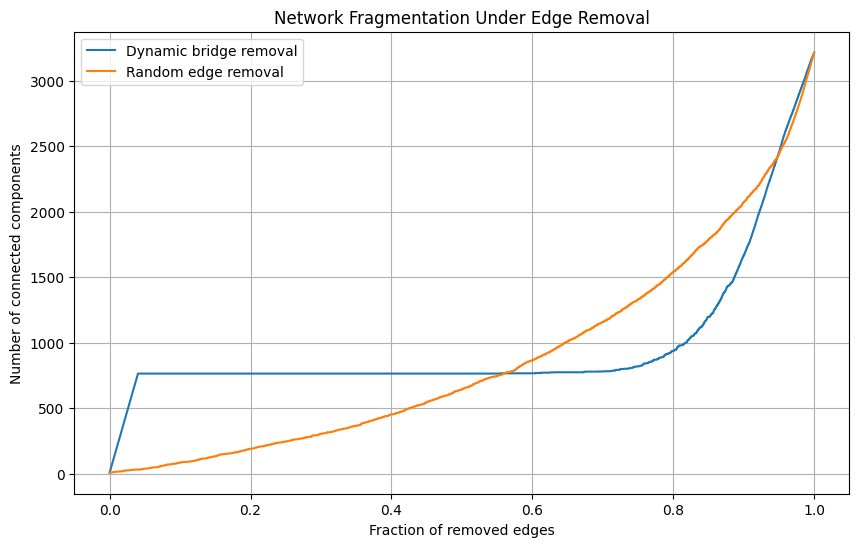

In [159]:
# plot connected components

plt.figure(figsize=(10,6))

plt.plot(
    x_bridge,
    c_bridge,
    label="Dynamic bridge removal"
)

plt.plot(
    x_random,
    c_random,
    label="Random edge removal"
)

plt.xlabel("Fraction of removed edges")
plt.ylabel("Number of connected components")

plt.title(
    "Network Fragmentation Under Edge Removal"
)

plt.legend()
plt.grid(True)

plt.show()

#### Other


In [160]:
core_numbers = nx.core_number(G_undirected)

core_df = pd.DataFrame({
    "node": list(core_numbers.keys()),
    "airport": [id_to_name.get(n, "Unknown") for n in core_numbers.keys()],
    "core_number": list(core_numbers.values()),
    "degree": [G_undirected.degree[n] for n in core_numbers.keys()]
})

core_df.sort_values("core_number", ascending=False).head(30)

,node,airport,core_number,degree
1435,1435,Sheremetyevo International Airport,31,144
279,279,London Stansted Airport,31,153
245,245,Bristol Airport,31,73
282,282,Amsterdam Airport Schiphol,31,248
1017,1017,Dubai International Airport,31,185
270,270,Glasgow International Airport,31,63
242,242,Manchester Airport,31,148
597,597,Toulouse-Blagnac Airport,31,47
1408,1408,Pulkovo Airport,31,112
271,271,Edinburgh Airport,31,89


In [161]:
node_country = dict(zip(nodes[" id"].astype(int), nodes[" country"]))

country_art = pd.DataFrame({
    "node": list(articulation_points),
    "airport": [id_to_name.get(n, "Unknown") for n in articulation_points],
    "country": [node_country.get(n, "Unknown") for n in articulation_points],
    "degree": [G_undirected.degree[n] for n in articulation_points]
})

country_art["country"].value_counts().head(20)

country
United States       62
Brazil              21
Canada              21
Australia           17
Russia              12
China               10
Indonesia            9
Greenland            7
Colombia             7
United Kingdom       6
France               6
India                5
Sweden               4
Congo (Kinshasa)     4
Spain                4
Burma                4
Malaysia             4
Philippines          3
Vanuatu              3
Algeria              3
Name: count, dtype: int64